# Metodología de selección de variables

**Estado del notebook:** `design / methodology` (no resultados confirmatorios).

**Pregunta que responde:** qué protocolo de selección de variables se aplica dentro del *walk-forward* purgado para que el *subset* retenido sea defendible y reproducible.

**Importante:** el *subset* final realmente retenido **no se cierra aquí**. Sale de los *bundles* experimentales aguas abajo (`reports/validation/experiments/<study_id>/`). Aquí solo se documenta la **metodología**, su contrato congelado y un *fold* piloto para ilustrarla.

**No cubre:**
- distribuciones globales, *missingness* o correlaciones del *feature set* (`02_features/01_eda_features_intermedias.ipynb`),
- comparación metodológica de métodos de etiquetado (`02_features/02_evaluacion_etiquetado_targets.ipynb`),
- materialización del *modeling dataset* y gate pre-modelo (`03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb`),
- preexperimento FFD o screening de columnas (`04_preexperimento/`),
- el *subset* final retenido por el campeón (solo en *bundles* experimentales aguas abajo).

**Productos:** CSV de frecuencia de aparición por *feature* (`feature_presence_btcusdt_fixed_horizon.csv`) bajo `reports/eda/feature_selection_methodology/`.

## Contrato de selección en dos capas

1. **Prefiltro estructural** (sin `fit`, sin estadísticas del *target*): *allowlist* por inventario experimental, *lineage* de fuente, presupuestos por familia técnica y umbrales de cobertura / *missingness* / *staleness*.
2. **Selección empírica** *intra-fold* (con `fit` solo en *train* del *fold*): filtros de varianza nula, colinealidad, importancias *model-agnostic* (MDI, *permutation*), reglas de *top-k* / umbrales y seguimiento de estabilidad entre *folds*.

## *Anti-leakage*

Cualquier paso con `fit` (incluyendo escalado, imputación y selección empírica) **se ajusta exclusivamente sobre el *train* del *fold* actual** y se aplica congelado al *test*. Las secciones 4–6 ilustran el protocolo sobre el **primer *fold***; la sección 7 repite el *pipeline* en los primeros **8 *folds*** para estabilidad, **sin reentrenar nada fuera del *train* de cada *fold***.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise FileNotFoundError("No se encontró la raíz del repositorio (carpeta src/)")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from src.features.experimental_column_inventory import is_structural_exclusion_trainable
from src.targets.contract import (
    MODELING_DATASET_TARGET_COLUMNS,
    TargetMethod,
)
from src.targets.experiment_spec import (
    describe_structural_prefilter_contract,
    describe_two_layer_selection_contract,
)
from src.targets.supervised_dataset_workflow import build_target_config_from_method
from src.validation.walk_forward import (
    WalkForwardConfig,
    WalkForwardMode,
    generate_splits,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

PROCESSED_ROOT = ROOT / "data" / "03_processed"
REPORT_DIR = ROOT / "reports" / "eda" / "feature_selection_methodology"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print(f"Raíz del proyecto: {ROOT}")
print(f"Raíz de datos procesados: {PROCESSED_ROOT} (existe: {PROCESSED_ROOT.exists()})")
print(f"Directorio de reportes: {REPORT_DIR}")


Raíz del proyecto: /app
Raíz de datos procesados: /app/data/03_processed (existe: True)
Directorio de reportes: /app/data/08_reporting/feature_selection_methodology


## 1. Contrato congelado de selección en dos capas

Se vuelca el contrato del módulo de experimentos para que las decisiones de este notebook se mantengan ancladas al código y no se alejen del *pipeline* oficial. Cualquier cambio en estos campos exige actualizar `selection_policy_version`.


In [2]:
two_layer = describe_two_layer_selection_contract()
structural = describe_structural_prefilter_contract()

print("Metodología de selección:", two_layer["selection_methodology"])
print("Rol de las columnas seleccionadas:", two_layer["selected_feature_columns_role"])
print("Ámbito de la selección empírica:", two_layer["empirical_selection_scope"])
print("Ámbito de ajuste del selector empírico:", two_layer["empirical_selector_fit_scope"])

ORDERED_FILTERS_COLUMNS_ES = {
    "filter_id": "id_filtro",
    "purpose": "proposito",
    "discard_if": "descarta_si",
}
DISCARD_REASONS_COLUMNS_ES = {
    "reason_id": "id_motivo",
    "criterion": "criterio",
}

ordered_filters = (
    pd.DataFrame(structural["ordered_filters"])
    .set_index("position")
    .rename(columns=ORDERED_FILTERS_COLUMNS_ES)
    .rename_axis("posicion")
)
display(ordered_filters)

discard_reasons = pd.DataFrame(structural["discard_reasons"]).rename(
    columns=DISCARD_REASONS_COLUMNS_ES
)
display(discard_reasons)

print(json.dumps(structural["threshold_policy"], indent=2))


Metodología de selección: structural_then_fold_empirical
Rol de las columnas seleccionadas: structural_prefilter_candidate_set
Ámbito de la selección empírica: validated_fold
Ámbito de ajuste del selector empírico: train_only


,id_filtro,proposito,descarta_si
posicion,,,
1,experiment_inventory_allowlist,Resolver la identidad experimental y la allowl...,La columna no pertenece al inventario explicit...
2,structural_modeling_exclusions,Excluir por contrato estructural fuentes no mo...,La columna cae bajo una fuente descartada a ni...
3,non_trainable_audit_exclusion,Excluir columnas de auditoria o lineage no ent...,"La columna representa lineage, auditoria o enf..."
4,temporal_causality_and_eligibility,"Exigir causalidad, disponibilidad temporal rea...",La columna no esta disponible en el instante d...
5,warmup_coverage_missingness,"Filtrar columnas con warm-up inviable, cobertu...","La cobertura util, el warm-up minimo o la cali..."
6,deterministic_redundancy_pruning,Eliminar duplicados exactos y redundancias det...,Existe otra columna equivalente o estrictament...
7,technical_family_budget_enforcement,Aplicar limites por familias tecnicas y budget...,La columna excede el budget de su familia o qu...


,id_motivo,criterio
0,outside_experiment_inventory,Columna fuera del inventario estructural del e...
1,structural_modeling_exclusion,Excluida por politica estructural: fuente no m...
2,lineage_or_audit_column,Columna de lineage/auditoria no entrenable.
3,non_causal_or_not_decision_available,La columna no es causal o no esta disponible e...
4,temporal_staleness_policy_violation,La staleness estructural supera la politica te...
5,warmup_or_coverage_violation,Warm-up insuficiente o cobertura inviable para...
6,structural_missingness_violation,Missingness estructural incompatible con el mo...
7,deterministic_redundancy,Redundancia fuerte o duplicado determinista fr...
8,technical_family_budget_violation,La columna no cabe dentro de los limites de fa...


{
  "policy_version": "1.2.0",
  "min_warmup_coverage_ratio": 0.7,
  "min_coverage_ratio": 0.7,
  "max_missingness_ratio": 0.3,
  "max_staleness_ratio": 0.0,
  "source_ffill_bars_overrides": {},
  "ms_max_staleness_bars": null,
  "oc_max_staleness_bars": null,
  "deriv_staleness_bars_by_group": {}
}


### 1.1. Exclusiones estructurales cerradas antes de Optuna

Esta comprobación explicita el conjunto de nombres que el prefiltro estructural retira del universo entrenable (antes de cualquier selección *intra-fold*). La regla productiva es `is_structural_exclusion_trainable`: excluye columnas alineadas con el esquema de *target*/*metadata* del *dataset* de modelado y columnas cuyo nombre indica las fuentes de noticias descartadas a nivel estructural (`guardian_*`, `nytimes_*`, incluidos *lags* y extensiones similares).


In [3]:
STRUCTURAL_EXCLUSION_COLUMNS_ES = {
    "column": "columna",
    "group": "grupo",
}

# Solo nombres cubiertos por el contrato estructural: metadata/labels y fuentes
# guardian/nytimes descartadas (ilustrativo: columnas fijas y variantes lag)
STRUCTURAL_EXCLUSION_PROBE_COLUMNS = tuple(sorted(
    set(MODELING_DATASET_TARGET_COLUMNS)
    | {
        "guardian_article_count",
        "guardian_article_count_lag_1",
        "guardian_sentiment_mean",
        "guardian_sentiment_mean_lag_1",
        "nytimes_article_count",
        "nytimes_article_count_lag_1",
        "nytimes_sentiment_mean",
        "nytimes_sentiment_mean_lag_1",
    }
))

structural_exclusion_rows = []
for column in STRUCTURAL_EXCLUSION_PROBE_COLUMNS:
    if column in MODELING_DATASET_TARGET_COLUMNS:
        group = "target_or_modeling_metadata"
    elif column.startswith("guardian_"):
        group = "discarded_news_source_guardian"
    elif column.startswith("nytimes_"):
        group = "discarded_news_source_nytimes"
    else:
        group = "other"

    structural_exclusion_rows.append(
        {
            "column": column,
            "group": group,
            "excluded_by_is_structural_exclusion_trainable": is_structural_exclusion_trainable(column),
        }
    )

structural_exclusion_df = pd.DataFrame(structural_exclusion_rows)
# La sonda no incluye fuentes candidatas; toda fila debería marcar exclusión
assert bool(structural_exclusion_df["excluded_by_is_structural_exclusion_trainable"].all())

excluded_structural_columns = sorted(structural_exclusion_df["column"].tolist())
print(
    "Columnas excluidas estructuralmente por is_structural_exclusion_trainable: "
    f"{len(excluded_structural_columns)}"
)
display(
    structural_exclusion_df.sort_values(["group", "column"])[
        ["column", "group"]
    ]
    .rename(columns=STRUCTURAL_EXCLUSION_COLUMNS_ES)
    .reset_index(drop=True)
)


Columnas excluidas estructuralmente por is_structural_exclusion_trainable: 47


,columna,grupo
0,guardian_article_count,discarded_news_source_guardian
1,guardian_article_count_lag_1,discarded_news_source_guardian
2,guardian_sentiment_mean,discarded_news_source_guardian
3,guardian_sentiment_mean_lag_1,discarded_news_source_guardian
4,nytimes_article_count,discarded_news_source_nytimes
5,nytimes_article_count_lag_1,discarded_news_source_nytimes
6,nytimes_sentiment_mean,discarded_news_source_nytimes
7,nytimes_sentiment_mean_lag_1,discarded_news_source_nytimes
8,avg_uniqueness,target_or_modeling_metadata
9,best_horizon_bars,target_or_modeling_metadata


## 2. Carga del *dataset* supervisado piloto

Se usa el *modeling dataset* canónico de `BTCUSDT / fixed_horizon` como piloto. Si el parquet no existe, se interrumpe con un mensaje que apunta al notebook de materialización en `03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb`.


In [4]:
PILOT_SYMBOL = "BTCUSDT"
PILOT_METHOD = TargetMethod.FIXED_HORIZON

modeling_path = (
    PROCESSED_ROOT
    / "datasets"
    / PILOT_SYMBOL
    / PILOT_METHOD.value
    / "modeling_dataset_4h.parquet"
)
if not modeling_path.exists():
    raise FileNotFoundError(
        f"No existe el modeling dataset piloto: {modeling_path}.\n"
        "Materialícelo primero ejecutando la corrida reproducible de "
        "03_dataset_supervisado/01_evidencia_dataset_modelado.ipynb"
    )

modeling_df = pd.read_parquet(modeling_path)
if "decision_ts" in modeling_df.columns:
    modeling_df["decision_ts"] = pd.to_datetime(modeling_df["decision_ts"])
    modeling_df = modeling_df.set_index("decision_ts").sort_index()

if "target_label" in modeling_df.columns:
    target_col = "target_label"
else:
    target_col = "label_side"

all_columns = set(modeling_df.columns)
target_metadata_columns = {col for col in all_columns if col in MODELING_DATASET_TARGET_COLUMNS}

feature_cols = sorted(
    col
    for col in all_columns
    if col not in target_metadata_columns
    and col != target_col
    and pd.api.types.is_numeric_dtype(modeling_df[col])
)

print(f"Dataset de modelado: {modeling_path.relative_to(ROOT)}")
print(f"Filas: {len(modeling_df):,} | Rango: {modeling_df.index.min()} -> {modeling_df.index.max()}")
print(f"Columna de target usada: {target_col}")
print(f"Columnas de target/metadata excluidas: {len(target_metadata_columns)}")
print(f"Columnas de feature candidatas (numéricas): {len(feature_cols)}")


Dataset de modelado: data/03_processed/datasets/BTCUSDT/fixed_horizon/modeling_dataset_4h.parquet
Filas: 18,707 | Rango: 2017-08-17 04:00:00 -> 2026-02-28 20:00:00
Columna de target usada: target_label
Columnas de target/metadata excluidas: 27
Columnas de feature candidatas (numéricas): 123


## 3. Plan *walk-forward* del *fold* piloto

Se construye un `WalkForwardConfig` con `purge` y `embargo` derivados del horizonte máximo del *label* (`6` barras de 4h en ambos casos). Toda la metodología de selección se ilustra sobre el primer *fold* (secciones 4–6); la sección 7 vuelve a aplicarla sobre los primeros **8 *folds*** (`MAX_FOLDS_FOR_STABILITY`) para medir estabilidad, suficiente para ilustrar el protocolo sin recorrer los **97** *folds* generados.


In [5]:
target_cfg = build_target_config_from_method(PILOT_METHOD, horizon_bars=6)
wf_config = WalkForwardConfig.from_target_config(
    target_cfg,
    mode=WalkForwardMode.SLIDING,
    train_bars=1080,
    test_bars=180,
    step_bars=180,
    min_train_bars=252,
)
wf_plan = generate_splits(modeling_df.index, wf_config)

print(f"Folds generados: {wf_plan.n_folds}")
print(f"Barras de purga: {wf_config.purge_bars} | Barras de embargo: {wf_config.embargo_bars}")
for fold in wf_plan.folds[:5]:
    print(
        f"  fold {fold.fold_id}: train {fold.train_start} -> {fold.train_end} "
        f"(n={fold.n_train}) | test {fold.test_start} -> {fold.test_end} (n={fold.n_test})"
    )

if wf_plan.n_folds == 0:
    raise RuntimeError("El plan walk-forward no produjo folds; revisa los parámetros")
pilot_fold = wf_plan.folds[0]


2026-05-27 13:02:14 [debug    ] fold_generated                 component=walk_forward fold_id=0 n_test=180 n_train=1080 test_range=2018-02-14 04:00:00 -> 2018-03-16 00:00:00 train_range=2017-08-17 04:00:00 -> 2018-02-13 00:00:00
2026-05-27 13:02:14 [debug    ] fold_generated                 component=walk_forward fold_id=1 n_test=180 n_train=1080 test_range=2018-03-16 04:00:00 -> 2018-04-15 00:00:00 train_range=2017-09-16 04:00:00 -> 2018-03-15 00:00:00
2026-05-27 13:02:14 [debug    ] fold_generated                 component=walk_forward fold_id=2 n_test=180 n_train=1080 test_range=2018-04-15 04:00:00 -> 2018-05-15 00:00:00 train_range=2017-10-16 04:00:00 -> 2018-04-14 00:00:00
2026-05-27 13:02:14 [debug    ] fold_generated                 component=walk_forward fold_id=3 n_test=180 n_train=1080 test_range=2018-05-15 04:00:00 -> 2018-06-14 00:00:00 train_range=2017-11-15 04:00:00 -> 2018-05-14 00:00:00
2026-05-27 13:02:14 [debug    ] fold_generated                 component=walk_forwar

## 4. Filtros estructurales (sin `fit`)

Se aplican sobre la matriz **completa** (no usan estadísticas del *target*) y siguen el orden del contrato:

1. Varianza nula -> columnas constantes o sin datos en *train* se descartan (`nunique(dropna=True) <= 1` cubre ambos casos; en *folds* tempranos esto suele atrapar fuentes con histórico posterior al inicio del *train*, como *funding rate*, microestructura o *Google Trends*).
2. *Missingness* fuera de *warm-up* -> columnas con tasa de nulos por encima del umbral del contrato.
3. Colinealidad fuerte -> dado un par con `|corr| >= COLINEARITY_THRESHOLD`, se conserva la primera por orden alfabético (regla determinista); en el *backbone* OHLCV esto suele eliminar duplicados casi exactos como `close`, `open`, `high`, `low`, `ema_*` y `sma_*` frente a `bbands_lower_20`.

Estos filtros son ilustrativos del prefiltro estructural; el *pipeline* oficial usa `execute_structural_prefilter` con reportes auditables persistidos.


In [6]:
MISSINGNESS_THRESHOLD = float(structural["threshold_policy"]["max_missingness_ratio"] or 0.30)
COLINEARITY_THRESHOLD = 0.95

AUDIT_DISCARD_COUNT_COLUMNS_ES = {"discarded_columns": "columnas_descartadas"}
AUDIT_DETAIL_COLUMNS_ES = {
    "column": "columna",
    "reason_id": "id_motivo",
    "missingness": "tasa_nulos",
    "max_abs_corr": "corr_abs_max",
    "correlated_with": "correlacion_con",
}


def structural_filters(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    *,
    missingness_threshold: float,
    colinearity_threshold: float,
) -> dict[str, object]:
    cols = list(feature_cols)
    audit: list[dict[str, object]] = []

    constant_mask = train_df[cols].nunique(dropna=True) <= 1
    constants = constant_mask[constant_mask].index.tolist()
    cols = [c for c in cols if c not in constants]
    audit.extend({"column": c, "reason_id": "zero_variance"} for c in constants)

    missingness = train_df[cols].isna().mean()
    high_missing = missingness[missingness > missingness_threshold].index.tolist()
    cols = [c for c in cols if c not in high_missing]
    audit.extend(
        {
            "column": c,
            "reason_id": "missingness_above_threshold",
            "missingness": float(missingness[c]),
        }
        for c in high_missing
    )

    if len(cols) > 1:
        corr = train_df[cols].corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        to_drop: list[str] = []
        for col in sorted(upper.columns):
            partners = upper.index[upper[col] >= colinearity_threshold].tolist()
            partners = [p for p in partners if p not in to_drop]
            if partners:
                to_drop.append(col)
                audit.append(
                    {
                        "column": col,
                        "reason_id": "high_collinearity",
                        "max_abs_corr": float(upper[col].max()),
                        "correlated_with": partners,
                    }
                )
        cols = [c for c in cols if c not in to_drop]

    return {"survivors": cols, "audit": audit}


fold_train = modeling_df.loc[pilot_fold.train_idx]

structural_outcome = structural_filters(
    fold_train,
    feature_cols,
    missingness_threshold=MISSINGNESS_THRESHOLD,
    colinearity_threshold=COLINEARITY_THRESHOLD,
)

print(f"Features candidatas iniciales: {len(feature_cols)}")
print(f"Sobreviven al prefiltro estructural ilustrativo: {len(structural_outcome['survivors'])}")
audit_df = pd.DataFrame(structural_outcome["audit"])
if not audit_df.empty:
    display(
        audit_df.groupby("reason_id")
        .size()
        .rename("discarded_columns")
        .to_frame()
        .rename_axis("id_motivo")
        .rename(columns=AUDIT_DISCARD_COUNT_COLUMNS_ES)
    )
    display(audit_df.head(10).rename(columns=AUDIT_DETAIL_COLUMNS_ES))


Features candidatas iniciales: 123
Sobreviven al prefiltro estructural ilustrativo: 39


,columnas_descartadas
id_motivo,
high_collinearity,18
zero_variance,66


,columna,id_motivo,corr_abs_max,correlacion_con
0,fr_mark_price,zero_variance,NaN,NaN
1,funding_rate,zero_variance,NaN,NaN
2,funding_rate_cum_24h,zero_variance,NaN,NaN
3,funding_rate_cum_3d,zero_variance,NaN,NaN
4,funding_rate_cum_7d,zero_variance,NaN,NaN
5,funding_rate_zscore_rolling,zero_variance,NaN,NaN
6,funding_regime_flag,zero_variance,NaN,NaN
7,funding_x_ls_spread,zero_variance,NaN,NaN
8,funding_x_oi_change,zero_variance,NaN,NaN
9,gt_bitcoin_imputed,zero_variance,NaN,NaN


## 5. Importancias *model-agnostic* en el *fold* piloto

Sobre el *subset* que sobrevive al prefiltro estructural, se calculan dos vistas complementarias de importancia, ambas ajustadas **solo en *train***:

- **MDI** (*Mean Decrease Impurity*) con un `RandomForestClassifier` ligero -> rápido pero sesgado a variables de alta cardinalidad.
- *Permutation importance* con `LogisticRegression` regularizada sobre *features* escalados -> *model-agnostic*, más robusto a colinealidades residuales.

Las métricas se calculan **sobre el *train* del *fold***; el *test* queda intacto para que pueda usarse aguas abajo en el estudio confirmatorio.


,variable,mdi,permutacion_media,permutacion_std
1,bbands_lower_20,0.0333,0.1017,0.0052
29,rolling_std_20,0.0382,0.0883,0.0074
38,wiki_views,0.0293,0.0388,0.0149
18,obv,0.0274,0.0377,0.0096
23,pvt,0.0315,0.0291,0.0024
2,bbands_pctb_20,0.0352,0.0219,0.0090
31,slope_sma_20,0.0312,0.0146,0.0032
14,ms_total_volume,0.0259,0.0105,0.0041
28,roc_12,0.0356,0.0103,0.0082
4,gt_bitcoin_price_lag_1,0.0240,0.0056,0.0026


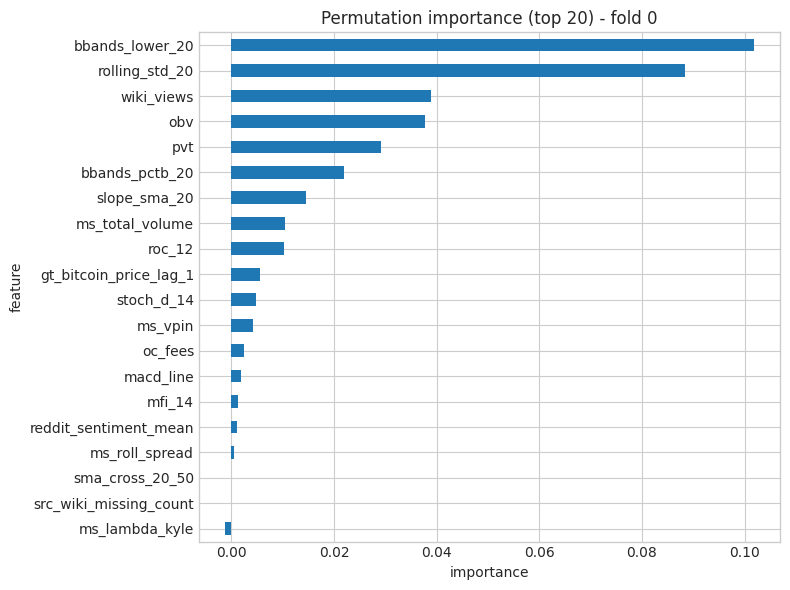

In [7]:
IMPORTANCE_COLUMNS_ES = {
    "feature": "variable",
    "mdi": "mdi",
    "permutation_mean": "permutacion_media",
    "permutation_std": "permutacion_std",
}


def build_xy(
    frame: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
) -> tuple[pd.DataFrame, pd.Series]:
    sub = frame[feature_cols + [target_col]].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
    X = sub[feature_cols]
    y = sub[target_col].astype(int)
    return X, y


def fold_importances(
    train_df: pd.DataFrame,
    feature_cols: list[str],
    target_col: str,
    *,
    random_state: int = RANDOM_STATE,
    permutation_repeats: int = 5,
) -> pd.DataFrame:
    X_train, y_train = build_xy(train_df, feature_cols, target_col)
    if X_train.empty or y_train.nunique() < 2:
        return pd.DataFrame(columns=["feature", "mdi", "permutation_mean", "permutation_std"])

    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        n_jobs=-1,
        random_state=random_state,
        class_weight="balanced_subsample",
    )
    rf.fit(X_train, y_train)
    mdi = pd.Series(rf.feature_importances_, index=feature_cols, name="mdi")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    logit = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        multi_class="auto",
        random_state=random_state,
    )
    logit.fit(X_train_scaled, y_train)
    perm = permutation_importance(
        logit,
        X_train_scaled,
        y_train,
        n_repeats=permutation_repeats,
        random_state=random_state,
        n_jobs=-1,
    )
    perm_mean = pd.Series(perm.importances_mean, index=feature_cols, name="permutation_mean")
    perm_std = pd.Series(perm.importances_std, index=feature_cols, name="permutation_std")

    out = pd.concat([mdi, perm_mean, perm_std], axis=1).reset_index(names="feature")
    return out.sort_values("permutation_mean", ascending=False)


survivors = structural_outcome["survivors"]
imp_pilot = fold_importances(fold_train, survivors, target_col)
display(imp_pilot.head(15).rename(columns=IMPORTANCE_COLUMNS_ES))

fig, ax = plt.subplots(figsize=(8, 6))
imp_pilot.head(20).set_index("feature")["permutation_mean"].iloc[::-1].plot(
    kind="barh", ax=ax
)
ax.set_title(f"Permutation importance (top 20) - fold {pilot_fold.fold_id}")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()


## 6. Regla de selección empírica

La regla por *fold* se define como `top_k` por `permutation_mean` con un piso mínimo de importancia para evitar el problema de retener variables irrelevantes solo por estar dentro del `top_k`. Los umbrales son explícitos y versionables.


In [8]:
TOP_K = 25
MIN_PERMUTATION_IMPORTANCE = 1e-4


def select_features(importances: pd.DataFrame) -> list[str]:
    if importances.empty:
        return []
    eligible = importances[importances["permutation_mean"] >= MIN_PERMUTATION_IMPORTANCE]
    return eligible.head(TOP_K)["feature"].tolist()


selected_pilot = select_features(imp_pilot)
print(f"Selección en fold {pilot_fold.fold_id}: {len(selected_pilot)} features")
print(selected_pilot)


Selección en fold 0: 17 features
['bbands_lower_20', 'rolling_std_20', 'wiki_views', 'obv', 'pvt', 'bbands_pctb_20', 'slope_sma_20', 'ms_total_volume', 'roc_12', 'gt_bitcoin_price_lag_1', 'stoch_d_14', 'ms_vpin', 'oc_fees', 'macd_line', 'mfi_14', 'reddit_sentiment_mean', 'ms_roll_spread']


## 7. Estabilidad de selección entre *folds*

Repetimos el *pipeline* (filtro estructural + importancias + regla `top_k`) en cada *fold* del *walk-forward*. Reportamos:

- Frecuencia de aparición por *feature* -> *proxy* de robustez.
- Índice de Jaccard medio entre *folds* consecutivos -> *proxy* de consistencia temporal.

Una baja estabilidad obliga a documentar la incertidumbre del *subset* retenido aguas abajo, no a esconderla.


In [9]:
MAX_FOLDS_FOR_STABILITY = min(wf_plan.n_folds, 8)
selections_per_fold: dict[int, list[str]] = {}

for fold in wf_plan.folds[:MAX_FOLDS_FOR_STABILITY]:
    train_slice = modeling_df.loc[fold.train_idx]
    structural_fold = structural_filters(
        train_slice,
        feature_cols,
        missingness_threshold=MISSINGNESS_THRESHOLD,
        colinearity_threshold=COLINEARITY_THRESHOLD,
    )
    fold_survivors = structural_fold["survivors"]
    importances = fold_importances(train_slice, fold_survivors, target_col)
    selections_per_fold[fold.fold_id] = select_features(importances)

SELECTION_SUMMARY_COLUMNS_ES = {"n_selected": "n_seleccionadas"}
FREQUENCY_COLUMNS_ES = {
    "index": "variable",
    "folds_presente": "folds_presente",
    "ratio_presencia": "ratio_presencia",
}

selection_summary = []
for fold_id, features in selections_per_fold.items():
    selection_summary.append({"fold_id": fold_id, "n_selected": len(features)})
display(
    pd.DataFrame(selection_summary)
    .rename(columns=SELECTION_SUMMARY_COLUMNS_ES)
    .set_index("fold_id")
    .rename_axis("id_fold")
)

all_features = sorted({feat for feats in selections_per_fold.values() for feat in feats})
freq = pd.Series(
    {
        feat: sum(feat in feats for feats in selections_per_fold.values())
        for feat in all_features
    },
    name="folds_presente",
).sort_values(ascending=False)
freq_df = freq.reset_index().rename(columns=FREQUENCY_COLUMNS_ES)
freq_df["ratio_presencia"] = freq_df["folds_presente"] / max(len(selections_per_fold), 1)
display(freq_df.head(20))

freq_path = REPORT_DIR / f"feature_presence_{PILOT_SYMBOL.lower()}_{PILOT_METHOD.value}.csv"
freq_df.to_csv(freq_path, index=False)
print(f"Frecuencia por feature persistida en: {freq_path}")


,n_seleccionadas
id_fold,
0,17
1,25
2,25
3,25
4,25
5,25
6,25
7,25


,variable,folds_presente,ratio_presencia
0,rolling_std_20,8,1.0000
1,macd_line,8,1.0000
2,obv,8,1.0000
3,bbands_lower_20,8,1.0000
4,ms_total_volume,8,1.0000
5,roc_12,8,1.0000
6,atr_14,7,0.8750
7,bbands_pctb_20,7,0.8750
8,gt_bitcoin,7,0.8750
9,rsi_14,6,0.7500


Frecuencia por feature persistida en: /app/data/08_reporting/feature_selection_methodology/feature_presence_btcusdt_fixed_horizon.csv


In [10]:
JACCARD_COLUMNS_ES = {"fold_pair": "par_folds", "jaccard": "jaccard"}

fold_ids = list(selections_per_fold.keys())
jaccard_pairs = []
for i, j in zip(fold_ids[:-1], fold_ids[1:]):
    a = set(selections_per_fold[i])
    b = set(selections_per_fold[j])
    if not a and not b:
        jaccard = float("nan")
    else:
        jaccard = len(a & b) / max(len(a | b), 1)
    jaccard_pairs.append({"fold_pair": f"{i}->{j}", "jaccard": jaccard})
jaccard_df = pd.DataFrame(jaccard_pairs).rename(columns=JACCARD_COLUMNS_ES)
display(jaccard_df)

if not jaccard_df.empty:
    print(
        f"Jaccard medio entre folds consecutivos: {jaccard_df['jaccard'].mean():.3f}"
    )


,par_folds,jaccard
0,0->1,0.4000
1,1->2,0.5152
2,2->3,0.6129
3,3->4,0.5625
4,4->5,0.4706
5,5->6,0.5152
6,6->7,0.5152


Jaccard medio entre folds consecutivos: 0.513


## 8. Cierre metodológico

- El *subset* final de *features* **no se cierra** en este notebook. Se documenta solo el protocolo en dos capas y los umbrales explícitos para reproducirlo en el *pipeline* oficial.
- Cualquier paso con `fit` (escalado, importancias, selección) se ajusta exclusivamente sobre el *train* del *fold*; el *test* no participa en la calibración.
- El *subset* realmente retenido por el campeón de la memoria aparece en `reports/validation/experiments/<study_id>/` y se interpreta en los notebooks de evidencia y síntesis bajo `05_modelado_predictivo/` (Exp1 *baseline*: `01_evidencia_shortlist_baseline.ipynb`, `02_evidencia_robustez_fold_shortlist_baseline.ipynb`; Exp1.5 *meta-labeling*: `03_evidencia_shortlist_meta_labeling.ipynb`, `04_evidencia_robustez_fold_shortlist_meta_labeling.ipynb`; Exp2 y carriles de riesgo: `05_resumen_greedy_contextual.ipynb`–`08_resumen_carril_riesgo_meta_labeling_contextual.ipynb`); admisión y DSR/`N` apoyadas en utilidades compartidas bajo `evidence_utils/`.
- La estabilidad observada entre *folds* (Jaccard medio entre consecutivos **`0.513`** sobre los **8** *folds* piloto, con **6** variables presentes en los 8) debe reportarse como evidencia **moderada** de robustez junto al *subset* retenido, no como decisión de cierre: la rotación parcial entre *folds* es esperable por la evolución del régimen de mercado y de la cobertura de las fuentes opcionales, y el *subset* final se decide aguas abajo sobre el *bundle* del campeón.
